In [5]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "src").exists() else cwd.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import matplotlib.pyplot as plt
from src.features import build_features
from src.hmm_model import select_n_states

data_path = repo_root / "data" / "market_data.csv"
df = pd.read_csv(data_path, index_col=0, parse_dates=True)
feats = build_features(df)

scores = select_n_states(feats)
scores.round(1)

,log_likelihood,AIC,BIC
n_states,,,
2,-15955.1,31952.2,32095.1
3,-13098.2,26266.4,26504.5
4,-10842.1,21786.3,22133.3
5,-9402.5,18943.0,19412.6


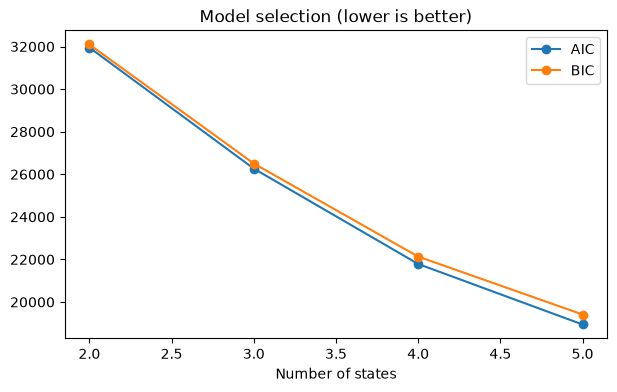

In [6]:
scores[["AIC", "BIC"]].plot(marker="o", figsize=(7, 4), title="Model selection (lower is better)")
plt.xlabel("Number of states")
plt.savefig("../results/figures/state_selection.png", dpi=150)
plt.show()